In [1]:
"""Bank customer churn with neural networks (MLP variants) vs logistic regression and gradient boosting.

Pipeline: simulate customers -> SQLite -> SQL cleaning + segment queries -> hypothesis tests ->
60/20/20 stratified train/validation/test split -> impute/scale/one-hot -> tuned models ->
model selection on VALIDATION AUC, final scores on the untouched TEST set -> save models + config.

DATA: SIMULATED (seed 42, 10,000 customers with duplicates and missing values added on purpose).
To use real data, replace the `customers_raw` table with your own table using the same columns.

Run: python churn_nn.py    (QUICK=1 python churn_nn.py for a fast smoke test)
"""

'Bank customer churn with neural networks (MLP variants) vs logistic regression and gradient boosting.\n\nPipeline: simulate customers -> SQLite -> SQL cleaning + segment queries -> hypothesis tests ->\n60/20/20 stratified train/validation/test split -> impute/scale/one-hot -> tuned models ->\nmodel selection on VALIDATION AUC, final scores on the untouched TEST set -> save models + config.\n\nDATA: SIMULATED (seed 42, 10,000 customers with duplicates and missing values added on purpose).\nTo use real data, replace the `customers_raw` table with your own table using the same columns.\n\nRun: python churn_nn.py    (QUICK=1 python churn_nn.py for a fast smoke test)\n'

In [2]:
import json
import os
import sqlite3
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from scipy import stats
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, brier_score_loss, roc_auc_score, roc_curve
from sklearn.model_selection import GridSearchCV, ParameterGrid, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

SEED = 42
QUICK = os.getenv("QUICK", "0") == "1"
DB_PATH = "bank.db"
MODEL_DIR = Path("saved_models")
BATCH = 256
EPOCHS, PATIENCE = (5, 2) if QUICK else (100, 10)

np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

In [3]:
def simulate_customers(n: int = 10_000, seed: int = SEED) -> pd.DataFrame:
    rng = np.random.default_rng(seed)
    df = pd.DataFrame({
        "customer_id": np.arange(1, n + 1),
        "region": rng.choice(["Greater Accra", "Ashanti", "Western", "Northern", "Eastern"], n,
                             p=[0.35, 0.25, 0.15, 0.12, 0.13]),
        "age": np.clip(rng.normal(38, 11, n), 18, 80).round(),
        "tenure_months": rng.integers(1, 121, n),
        "avg_monthly_balance": np.round(rng.lognormal(7.2, 1.0, n), 2),        # GHS
        "num_products": rng.choice([1, 2, 3, 4], n, p=[0.45, 0.35, 0.15, 0.05]),
        "has_credit_card": rng.binomial(1, 0.35, n),
        "digital_logins_per_month": rng.poisson(6, n),
        "complaints_last_year": rng.poisson(0.3, n),
    })
    z = (-1.9
         + 0.8 * df["complaints_last_year"].clip(upper=3)
         - 0.08 * (df["digital_logins_per_month"] - 6)
         + 0.6 * (df["num_products"] >= 3)
         - 0.3 * (df["num_products"] == 2)
         + 0.02 * (df["age"] - 38)
         - 0.008 * df["tenure_months"]
         - 0.25 * (np.log(df["avg_monthly_balance"]) - 7.2))
    df["churned"] = rng.binomial(1, 1 / (1 + np.exp(-z)))
    df.loc[rng.random(n) < 0.03, "age"] = np.nan
    df.loc[rng.random(n) < 0.03, "avg_monthly_balance"] = np.nan
    return pd.concat([df, df.sample(frac=0.01, random_state=1)], ignore_index=True)


raw = simulate_customers()
with sqlite3.connect(DB_PATH) as con:
    raw.to_sql("customers_raw", con, if_exists="replace", index=False)
print(f"customers_raw: {len(raw):,} rows")

customers_raw: 10,100 rows


In [4]:
CLEAN_SQL = """
DROP TABLE IF EXISTS customers;
CREATE TABLE customers AS
SELECT customer_id, region, age, tenure_months, avg_monthly_balance, num_products,
       has_credit_card, digital_logins_per_month, complaints_last_year, churned
FROM (
    SELECT *, ROW_NUMBER() OVER (PARTITION BY customer_id ORDER BY customer_id) AS rn
    FROM customers_raw
)
WHERE rn = 1;

DROP VIEW IF EXISTS customer_features;
CREATE VIEW customer_features AS
SELECT *,
       CASE WHEN complaints_last_year > 0 THEN 1 ELSE 0 END AS has_complaint,
       CASE WHEN digital_logins_per_month <= 2 THEN 'low'
            WHEN digital_logins_per_month <= 8 THEN 'medium'
            ELSE 'high' END AS digital_engagement
FROM customers;
"""
SEGMENT_SQL = """
SELECT 'region' AS segment, region AS value, COUNT(*) AS customers, ROUND(AVG(churned) * 100, 1) AS churn_pct
FROM customer_features GROUP BY region
UNION ALL
SELECT 'num_products', CAST(num_products AS TEXT), COUNT(*), ROUND(AVG(churned) * 100, 1)
FROM customer_features GROUP BY num_products
UNION ALL
SELECT 'has_complaint', CAST(has_complaint AS TEXT), COUNT(*), ROUND(AVG(churned) * 100, 1)
FROM customer_features GROUP BY has_complaint
UNION ALL
SELECT 'digital_engagement', digital_engagement, COUNT(*), ROUND(AVG(churned) * 100, 1)
FROM customer_features GROUP BY digital_engagement
ORDER BY segment, value;
"""
with sqlite3.connect(DB_PATH) as con:
    con.executescript(CLEAN_SQL)
    segments = pd.read_sql_query(SEGMENT_SQL, con)
    df = pd.read_sql_query("SELECT * FROM customer_features", con)
print(f"after de-duplication: {len(df):,} customers | churn rate {df['churned'].mean():.1%}")
print(segments.to_string(index=False))

after de-duplication: 10,000 customers | churn rate 12.4%
           segment         value  customers  churn_pct
digital_engagement          high       1544        9.6
digital_engagement           low        591       15.4
digital_engagement        medium       7865       12.8
     has_complaint             0       7444        9.3
     has_complaint             1       2556       21.4
      num_products             1       4424       12.1
      num_products             2       3527        8.8
      num_products             3       1530       19.0
      num_products             4        519       20.2
            region       Ashanti       2506       12.3
            region       Eastern       1267       11.9
            region Greater Accra       3542       12.6
            region      Northern       1175       12.3
            region       Western       1510       12.6


In [5]:
ct = pd.crosstab(df["has_complaint"], df["churned"])
chi2, p_chi, _, _ = stats.chi2_contingency(ct)
odds_ratio = (ct.loc[1, 1] * ct.loc[0, 0]) / (ct.loc[1, 0] * ct.loc[0, 1])
print(f"Complaint vs churn: chi2={chi2:.1f}, p={p_chi:.2e}, odds ratio={odds_ratio:.2f}")

u, p_mw = stats.mannwhitneyu(df.loc[df.churned == 1, "tenure_months"], df.loc[df.churned == 0, "tenure_months"])
print(f"Tenure churned vs retained: Mann-Whitney p={p_mw:.2e}; medians "
      f"{df.loc[df.churned == 1, 'tenure_months'].median():.0f} vs {df.loc[df.churned == 0, 'tenure_months'].median():.0f} months")

Complaint vs churn: chi2=251.3, p=1.37e-56, odds ratio=2.63
Tenure churned vs retained: Mann-Whitney p=4.33e-11; medians 52 vs 62 months


In [6]:
NUMERIC = ["age", "tenure_months", "log_balance", "num_products", "has_credit_card",
           "digital_logins_per_month", "complaints_last_year"]
CATEGORICAL = ["region"]


def add_features(d: pd.DataFrame) -> pd.DataFrame:
    d = d.copy()
    d["log_balance"] = np.log(d["avg_monthly_balance"])       # NaN stays NaN and is imputed later
    return d[NUMERIC + CATEGORICAL]


def make_preprocessor():
    num = Pipeline([("imputer", SimpleImputer(strategy="median", add_indicator=True)), ("scaler", StandardScaler())])
    return ColumnTransformer([("num", num, NUMERIC),
                              ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), CATEGORICAL)])


X_all, y_all = add_features(df), df["churned"].to_numpy()
X_tr_df, X_tmp_df, y_tr, y_tmp = train_test_split(X_all, y_all, test_size=0.4, stratify=y_all, random_state=SEED)
X_va_df, X_te_df, y_va, y_te = train_test_split(X_tmp_df, y_tmp, test_size=0.5, stratify=y_tmp, random_state=SEED)

pre = make_preprocessor().fit(X_tr_df)
Xtr, Xva, Xte = (pre.transform(d).astype(np.float32) for d in (X_tr_df, X_va_df, X_te_df))
feature_names = list(pre.get_feature_names_out())
print("train/val/test:", len(y_tr), len(y_va), len(y_te), "| features:", Xtr.shape[1])


def compute_metrics(y_true, prob):
    top = np.argsort(-prob)[: max(1, len(prob) // 10)]
    return {"auc": roc_auc_score(y_true, prob), "ap": average_precision_score(y_true, prob),
            "brier": brier_score_loss(y_true, prob), "lift10": float(np.mean(y_true[top]) / np.mean(y_true))}

train/val/test: 6000 2000 2000 | features: 14


In [7]:
cv = StratifiedKFold(5, shuffle=True, random_state=SEED)

lr_search = GridSearchCV(LogisticRegression(max_iter=2000), {"C": [0.01, 0.1, 1.0, 10.0]}, scoring="roc_auc", cv=cv)
lr_search.fit(Xtr, y_tr)
print("Logistic regression best:", lr_search.best_params_)

hgb_grid = ({"learning_rate": [0.05], "max_depth": [3]} if QUICK else
            {"learning_rate": [0.03, 0.1], "max_iter": [100, 200], "max_depth": [2, 3, 5], "min_samples_leaf": [20, 50]})
hgb_search = GridSearchCV(HistGradientBoostingClassifier(l2_regularization=1.0, random_state=SEED), hgb_grid,
                          scoring="roc_auc", cv=cv)
hgb_search.fit(Xtr, y_tr)
print("HistGradientBoosting best:", hgb_search.best_params_)

Logistic regression best: {'C': 0.01}
HistGradientBoosting best: {'learning_rate': 0.1, 'max_depth': 2, 'max_iter': 100, 'min_samples_leaf': 50}


In [8]:
def make_nn(kind="mlp", n_features=Xtr.shape[1], units=64, dropout=0.2, learning_rate=0.001):
    L = tf.keras.layers
    inp = tf.keras.Input(shape=(n_features,))
    if kind == "mlp":
        x = L.Dropout(dropout)(L.Dense(units, activation="relu")(inp))
        x = L.Dropout(dropout)(L.Dense(units // 2, activation="relu")(x))
    elif kind == "mlp_bn":
        x = inp
        for u in (units, units // 2):
            x = L.Dropout(dropout)(L.Activation("relu")(L.BatchNormalization()(L.Dense(u)(x))))
    elif kind == "wide_deep":
        deep = L.Dropout(dropout)(L.Dense(units, activation="relu")(inp))
        deep = L.Dropout(dropout)(L.Dense(units // 2, activation="relu")(deep))
        x = L.Concatenate()([inp, deep])                     # 'wide' path = raw inputs feeding the output layer
    else:
        raise ValueError(kind)
    out = L.Dense(1, activation="sigmoid")(x)
    model = tf.keras.Model(inp, out)
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate), loss="binary_crossentropy",
                  metrics=[tf.keras.metrics.AUC(name="auc"), tf.keras.metrics.AUC(name="pr_auc", curve="PR")])
    return model


nn_grid = ({"units": [32], "dropout": [0.2], "learning_rate": [0.001]} if QUICK else
           {"units": [32, 64], "dropout": [0.0, 0.3], "learning_rate": [0.001, 0.003]})


def tune_nn(kind):
    best = {"val_auc": -np.inf, "params": None, "model": None, "history": None}
    for params in ParameterGrid(nn_grid):
        tf.keras.backend.clear_session()
        tf.keras.utils.set_random_seed(SEED)
        model = make_nn(kind, **params)
        es = tf.keras.callbacks.EarlyStopping(monitor="val_auc", mode="max", patience=PATIENCE, restore_best_weights=True)
        hist = model.fit(Xtr, y_tr, validation_data=(Xva, y_va), epochs=EPOCHS, batch_size=BATCH,
                         callbacks=[es], verbose=0)
        val_auc = max(hist.history["val_auc"])
        print(f"{kind} {params} -> val AUC {val_auc:.4f}")
        if val_auc > best["val_auc"]:
            best = {"val_auc": val_auc, "params": params, "model": model, "history": hist.history}
    return best


nn_results = {kind: tune_nn(kind) for kind in ("mlp", "mlp_bn", "wide_deep")}

mlp {'dropout': 0.0, 'learning_rate': 0.001, 'units': 32} -> val AUC 0.6834
mlp {'dropout': 0.0, 'learning_rate': 0.001, 'units': 64} -> val AUC 0.6808
mlp {'dropout': 0.0, 'learning_rate': 0.003, 'units': 32} -> val AUC 0.6863
mlp {'dropout': 0.0, 'learning_rate': 0.003, 'units': 64} -> val AUC 0.6829
mlp {'dropout': 0.3, 'learning_rate': 0.001, 'units': 32} -> val AUC 0.6870
mlp {'dropout': 0.3, 'learning_rate': 0.001, 'units': 64} -> val AUC 0.6839
mlp {'dropout': 0.3, 'learning_rate': 0.003, 'units': 32} -> val AUC 0.6886
mlp {'dropout': 0.3, 'learning_rate': 0.003, 'units': 64} -> val AUC 0.6846
mlp_bn {'dropout': 0.0, 'learning_rate': 0.001, 'units': 32} -> val AUC 0.6796
mlp_bn {'dropout': 0.0, 'learning_rate': 0.001, 'units': 64} -> val AUC 0.6713
mlp_bn {'dropout': 0.0, 'learning_rate': 0.003, 'units': 32} -> val AUC 0.6798
mlp_bn {'dropout': 0.0, 'learning_rate': 0.003, 'units': 64} -> val AUC 0.6759
mlp_bn {'dropout': 0.3, 'learning_rate': 0.001, 'units': 32} -> val AUC 0.68

In [9]:
predictors = {
    "Logistic regression": lambda X: lr_search.best_estimator_.predict_proba(X)[:, 1],
    "HistGradientBoosting": lambda X: hgb_search.best_estimator_.predict_proba(X)[:, 1],
    **{kind.upper(): (lambda X, m=res["model"]: m.predict(X, verbose=0).reshape(-1)) for kind, res in nn_results.items()},
}
rows, test_probs = [], {}
for name, predict in predictors.items():
    val_m, test_prob = compute_metrics(y_va, predict(Xva)), predict(Xte)
    test_probs[name] = test_prob
    test_m = compute_metrics(y_te, test_prob)
    rows.append({"Model": name, "Val AUC": val_m["auc"], "Test AUC": test_m["auc"], "Test AP": test_m["ap"],
                 "Test Brier": test_m["brier"], "Test top-decile lift": test_m["lift10"]})
model_results = pd.DataFrame(rows).sort_values("Val AUC", ascending=False).reset_index(drop=True)
best_name = model_results.loc[0, "Model"]
print(model_results.to_string(index=False, float_format=lambda v: f"{v:.4f}"))
print(f"\nBest model by validation AUC: {best_name}")
print(f"Base churn rate in test set: {y_te.mean():.1%}")

               Model  Val AUC  Test AUC  Test AP  Test Brier  Test top-decile lift
HistGradientBoosting   0.6962    0.6880   0.2963      0.1009                2.7823
           WIDE_DEEP   0.6925    0.6728   0.2773      0.1020                2.6613
              MLP_BN   0.6915    0.6680   0.2533      0.1043                2.5403
                 MLP   0.6884    0.6765   0.2834      0.1023                2.5000
 Logistic regression   0.6874    0.6710   0.2889      0.1016                2.5806

Best model by validation AUC: HistGradientBoosting
Base churn rate in test set: 12.4%


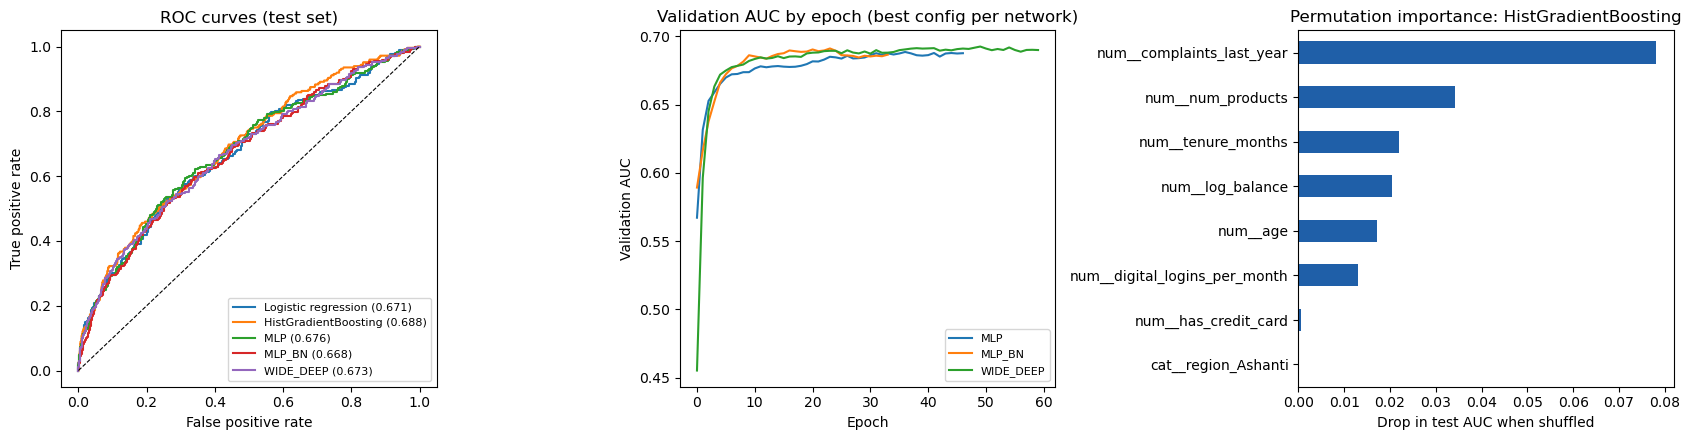

num__complaints_last_year        0.0780
num__num_products                0.0342
num__tenure_months               0.0219
num__log_balance                 0.0205
num__age                         0.0172
num__digital_logins_per_month    0.0130
num__has_credit_card             0.0005
cat__region_Ashanti              0.0000
dtype: float64


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
for name, prob in test_probs.items():
    fpr, tpr, _ = roc_curve(y_te, prob)
    axes[0].plot(fpr, tpr, label=f"{name} ({roc_auc_score(y_te, prob):.3f})")
axes[0].plot([0, 1], [0, 1], "k--", lw=0.8)
axes[0].set(title="ROC curves (test set)", xlabel="False positive rate", ylabel="True positive rate")
axes[0].legend(fontsize=8)

for kind, res in nn_results.items():
    axes[1].plot(res["history"]["val_auc"], label=kind.upper())
axes[1].set(title="Validation AUC by epoch (best config per network)", xlabel="Epoch", ylabel="Validation AUC")
axes[1].legend(fontsize=8)

best_predict = predictors[best_name]
rng = np.random.default_rng(SEED)
base_auc = roc_auc_score(y_te, best_predict(Xte))
drops = []
for j in range(Xte.shape[1]):
    reps = []
    for _ in range(3 if QUICK else 10):
        Xp = Xte.copy()
        Xp[:, j] = rng.permutation(Xp[:, j])
        reps.append(base_auc - roc_auc_score(y_te, best_predict(Xp)))
    drops.append(np.mean(reps))
importance = pd.Series(drops, index=feature_names).sort_values(ascending=False)
importance.head(8)[::-1].plot.barh(ax=axes[2], color="#1F5FA8")
axes[2].set(title=f"Permutation importance: {best_name}", xlabel="Drop in test AUC when shuffled")
plt.tight_layout()
plt.show()
print(importance.head(8).round(4))

In [11]:
prob = test_probs[best_name]
order = np.argsort(-prob)
decile = np.repeat(np.arange(1, 11), int(np.ceil(len(prob) / 10)))[: len(prob)]
gains = pd.DataFrame({"decile": decile, "churned": y_te[order]}).groupby("decile")["churned"].agg(["count", "sum", "mean"])
gains.columns = ["customers", "churners", "churn_rate"]
gains["share_of_all_churners"] = gains["churners"] / gains["churners"].sum()
gains["cumulative_share"] = gains["share_of_all_churners"].cumsum()
print(gains.to_string(float_format=lambda v: f"{v:.3f}"))

        customers  churners  churn_rate  share_of_all_churners  cumulative_share
decile                                                                          
1             200        69       0.345                  0.278             0.278
2             200        36       0.180                  0.145             0.423
3             200        25       0.125                  0.101             0.524
4             200        22       0.110                  0.089             0.613
5             200        26       0.130                  0.105             0.718
6             200        18       0.090                  0.073             0.790
7             200        19       0.095                  0.077             0.867
8             200        17       0.085                  0.069             0.935
9             200         9       0.045                  0.036             0.972
10            200         7       0.035                  0.028             1.000


In [12]:
MODEL_DIR.mkdir(exist_ok=True)
joblib.dump(pre, MODEL_DIR / "preprocessor.pkl")
joblib.dump(lr_search.best_estimator_, MODEL_DIR / "logistic_regression.pkl")
joblib.dump(hgb_search.best_estimator_, MODEL_DIR / "hist_gradient_boosting.pkl")
for kind, res in nn_results.items():
    res["model"].save(MODEL_DIR / f"{kind}_final.keras")
config = {"numeric": NUMERIC, "categorical": CATEGORICAL, "feature_names": feature_names, "best_model": best_name,
          "lr_params": lr_search.best_params_, "hgb_params": hgb_search.best_params_,
          "nn_params": {k: r["params"] for k, r in nn_results.items()}}
(MODEL_DIR / "model_config.json").write_text(json.dumps(config, indent=4, default=str))

1347

In [13]:
def score_customers(new_customers: pd.DataFrame) -> pd.DataFrame:
    """new_customers needs: region, age, tenure_months, avg_monthly_balance, num_products, has_credit_card,
    digital_logins_per_month, complaints_last_year. Returns churn probability and risk decile-style band."""
    X = pre.transform(add_features(new_customers)).astype(np.float32)
    out = new_customers.copy()
    out["churn_probability"] = predictors[best_name](X)
    out["risk_band"] = pd.cut(out["churn_probability"], [0, 0.10, 0.25, 1.0], labels=["low", "medium", "high"])
    return out


sample = df.drop(columns=["churned", "has_complaint", "digital_engagement"]).sample(5, random_state=SEED)
print(score_customers(sample)[["customer_id", "region", "churn_probability", "risk_band"]].to_string(index=False))

 customer_id        region  churn_probability risk_band
        6253       Ashanti           0.063206       low
        4685       Eastern           0.076592       low
        1732 Greater Accra           0.111373    medium
        4743      Northern           0.074020       low
        4522       Ashanti           0.316053      high
